In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('Social_Network_Ads.csv')

In [11]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [9]:
x = df[['Age','EstimatedSalary']]
y = df['Purchased']

In [19]:
from sklearn.preprocessing import (StandardScaler)
scaler = StandardScaler()
x_scaled_array = scaler.fit_transform(x)

In [22]:
x_scaled = pd.DataFrame(x_scaled_array,columns=x.columns)
x_scaled

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751
...,...,...
395,0.797057,-0.844019
396,1.274623,-1.372587
397,1.179110,-1.460681
398,-0.158074,-1.078938


In [113]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x_scaled,y,
                                                       random_state = 42,
                                                       test_size = 0.25)


In [114]:
from sklearn.linear_model import LogisticRegression

/tmp/ipykernel_8098/347856870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y,palette="Set1")


<Axes: xlabel='Purchased', ylabel='count'>

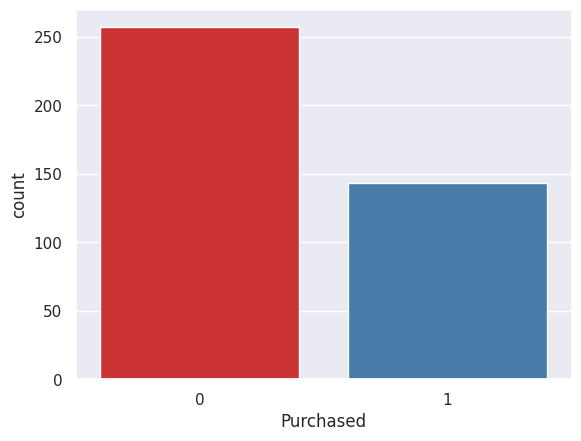

In [115]:
import seaborn as sns
sns.set_style('darkgrid')
sns.countplot(x=y,palette="Set1")

In [116]:
y.value_counts()

,count
Purchased,
0,257
1,143


In [117]:
classfier = LogisticRegression()
classfier.fit(x_train,y_train)

LogisticRegression()

In [118]:
y_pred = classfier.predict(x_test_scaled)

In [119]:
y_pred = pd.DataFrame(y_pred,columns=['Purchased_predictions'])

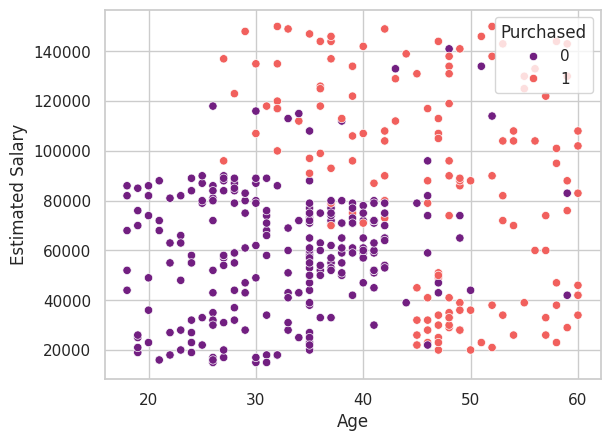

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.scatterplot(x=x['Age'], y=x['EstimatedSalary'], hue=y, palette='magma')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(title='Purchased', loc='upper right')
plt.show()


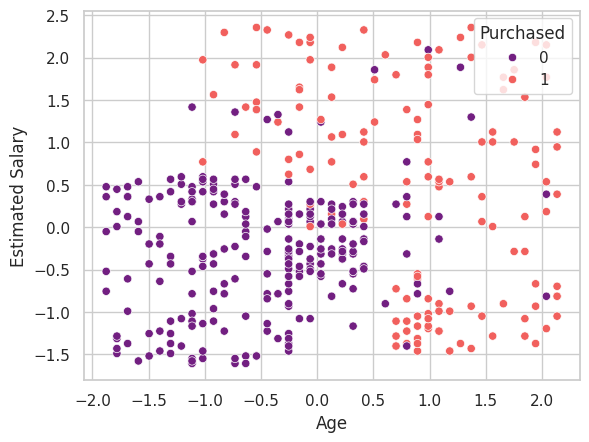

In [121]:
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
sns.scatterplot(x=x_scaled['Age'],y=x_scaled['EstimatedSalary'],hue=y,palette='magma')
plt.legend(title='Purchased', loc='upper right')
plt.show()

In [122]:
y_pred = classfier.predict(x_test)

In [123]:
y_pred.shape

(100,)

In [124]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[61,  2],
       [12, 25]])

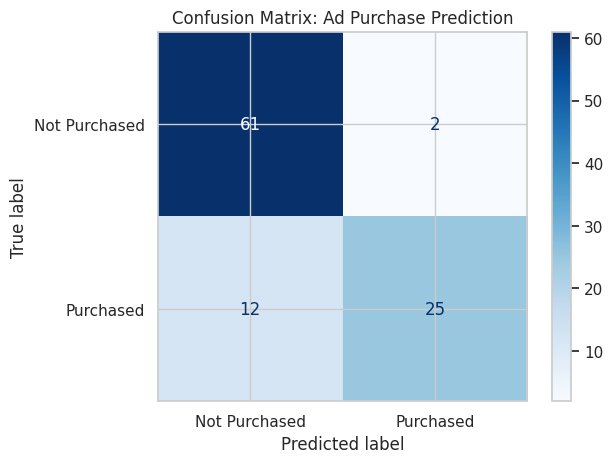

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmd = ConfusionMatrixDisplay.from_estimator(
    classfier,
    x_test, # expects raw data predicts itself
    y_test,
    display_labels=['Not Purchased', 'Purchased'],
    cmap='Blues'
)

# Optional: Add a title
plt.title('Confusion Matrix: Ad Purchase Prediction')
plt.show()



In [126]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

86.0